# 3. Background Removal with Robust PCA

 Background Removal with Robust PCA

## Goal

Separate moving objects from static backgrounds in video footage. Given a surveillance video, we want to extract two components:
- **Background**: The static, unchanging scene
- **Foreground**: The moving people, cars, or objects

This matters because manually tracking objects across thousands of video frames is tedious. Whether you're monitoring traffic flow, counting customers, or analyzing animal behavior, you need automated background removal.

## The Core Intuition

Think about a surveillance camera pointed at a parking lot. Over 100 frames:
- The asphalt, buildings, and parked cars appear in *every single frame* → redundant information
- A person walking through appears in *maybe 5 frames* → rare, sparse event

Robust PCA exploits this pattern. It decomposes your video matrix $M$ into:

$$M = L + S$$

Where:
- **$L$ (Low-rank)**: Captures repetitive patterns --> background. "Low-rank" means the matrix has lots of redundancy, which makes sense since the background is literally the same pixels repeated across frames.
- **$S$ (Sparse)**: Captures rare events --> foreground. "Sparse" means mostly zeros, just like how most pixels in most frames contain no moving objects.


![background removal](images/surveillance3.png)



## Getting Started

I am using a cleaned and well workable real video 003 dataset from [BMC 2012 Background Models Challenge Dataset](http://bmc.iut-auvergne.com/?page_id=24) cause of computational limitation of my laptop ( where taking a noisy or real world moving background scene thing kinda need a high scaling and that kinda melts my machine rn) and the relatively lack of sophistication of this linear Decomposition which need a real and well putout video to workout.

Many other datasets can be found in here:
- [Background Subtraction Website](https://sites.google.com/site/backgroundsubtraction/test-sequences)


---
It is a surveillance clip of people walking through a scene. It's 113 seconds of real-world footage, perfect for testing background removal.

The key trick is that we treat video as a matrix.
Each frame is 60×80 pixels (after downscaling). Instead of keeping it as a 2D image, we unroll it into a tall column of 4,800 values (60 × 80 = 4,800).
Now stack frames as columns. If we sample every tenth of a second:

- 113 seconds × 10 samples/second = 1,130 frames
- Each frame becomes a column of 4,800 pixels
- Final matrix: 4,800 × 1,130 (rows = pixels, columns = time points)

Each column is one moment frozen in time. Each row tracks how one pixel changes across the entire video.

Import needed libraries:

In [1]:
import moviepy as mpe
#from IPython.display import display
from glob import glob
from IPython.display import display, Video

In [2]:
import sys, os
import numpy as np
import scipy

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
# MAX_ITERS = 10
TOL = 1.0e-8

In [5]:
clip = mpe.VideoFileClip("images/video_003.avi")
clip.write_videofile("images/video_003.mp4")
display(Video("images/video_003.mp4", width=300, embed=True))

MoviePy - Building video data/video_003.mp4.
MoviePy - Writing video data/video_003.mp4



MoviePy - Done !
MoviePy - video ready data/video_003.mp4


In [6]:
clip.duration

113.57

### Helper Methods

In [6]:
from skimage.transform import rescale

def matrix_from_video(clip, k=5, scale=50):
    return np.vstack([rescale(rgb2gray(clip.get_frame(i/float(k))), 
                      scale/100.0, anti_aliasing=True).flatten() 
                      for i in range(k * int(clip.duration))]).T


In [7]:
def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.299, 0.587, 0.114])

In [8]:
def plt_images(M, A, E, index_array, dims, filename=None):
    f = plt.figure(figsize=(15, 10))
    r = len(index_array)
    pics = r * 3
    for k, i in enumerate(index_array):
        for j, mat in enumerate([M, A, E]):
            sp = f.add_subplot(r, 3, 3*k + j + 1)
            sp.axis('Off')
            pixels = mat[:,i]
            if isinstance(pixels, scipy.sparse.csr_matrix):
                pixels = pixels.todense()
            plt.imshow(np.reshape(pixels, dims), cmap='gray')
    return f

In [9]:
def plots(ims, dims, figsize=(15,20), rows=1, interp=False, titles=None):
    if type(ims[0]) is np.ndarray:
        ims = np.array(ims)
    f = plt.figure(figsize=figsize)
    for i in range(len(ims)):
        sp = f.add_subplot(rows, len(ims)//rows, i+1)
        sp.axis('Off')
        plt.imshow(np.reshape(ims[i], dims), cmap="gray")

### Load and view the data

An image from 1 moment in time is 60 pixels by 80 pixels (when scaled). We can *unroll* that picture into a single tall column. So instead of having a 2D picture that is $60 \times 80$, we have a $1 \times 4,800$ column 

This isn't very human-readable, but it's useful because it lets us stack the images from different times on top of one another, to put a video all into 1 matrix.  If we took the video image every tenth of a second for 113 seconds (so 11,300 different images, each from a different point in time), we'd have a $11300 \times 4800$ matrix, representing the video.

In [10]:
scale = 30
dims = (int(240 * (scale/100)), int(320 * (scale/100)))

In [11]:
#M = matrix_from_video(clip, 100, scale)
M = np.load("low_res_surveillance_matrix.npy")

In [13]:
print(dims, M.shape)

(72, 96) (6912, 11300)


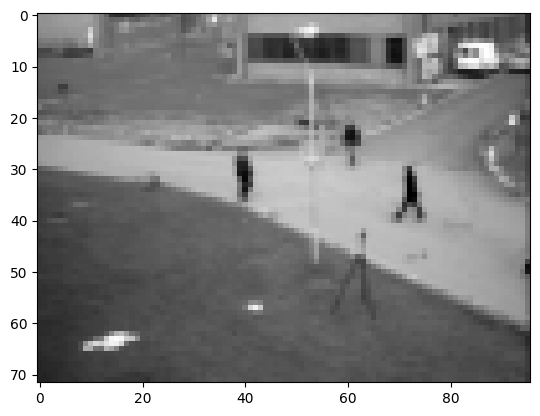

In [14]:
plt.imshow(np.reshape(M[:,140], dims), cmap='gray');

Since `matrix_from_video` is somewhat slow, we will save our matrix.  In general, whenever you have slow pre-processing steps, it's a good idea to save the results for future use.

In [15]:
np.save("low_res_surveillance_matrix.npy", M)

Note: High-res M is too big to plot, so only run the below with the low-res version

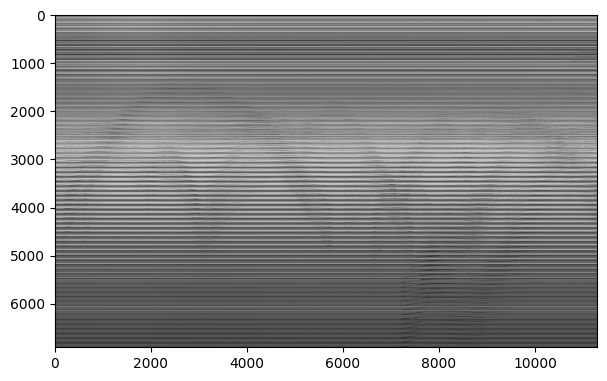

In [16]:
plt.figure(figsize=(12, 12))
plt.imshow(M, cmap='gray')

**Questions**: Those wavy black lines are what gives the dynamic content from the video which are sort of less relevant information provinding in terms of describing our whole stack of matrix sampled at 10th of a sec from the video. And those horizontal lines are the constant static background thing as it is remaining the same in every instant of time.

In [ ]:
plt.imsave(fname="image2.jpg", arr=np.reshape(M[:,140], dims), cmap='gray')

## SVD

We know this return the 

### A first attempt with SVD

In [26]:
from sklearn import decomposition

In [27]:
u, s, v = decomposition.randomized_svd(M, 2)

In [28]:
u.shape, s.shape, v.shape

((6912, 2), (2,), (2, 11300))

In [29]:
low_rank = u @ np.diag(s) @ v

In [19]:
low_rank.shape

(6912, 11300)

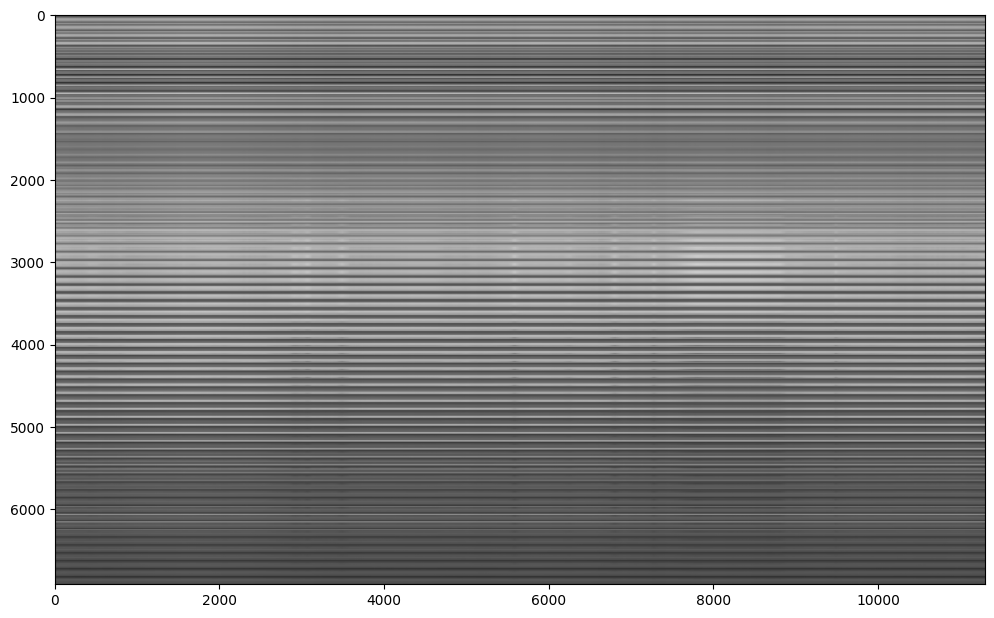

In [22]:
plt.figure(figsize=(12, 12))
plt.imshow(low_rank, cmap='gray')

The below images were created with high-res data.  Very slow to process:

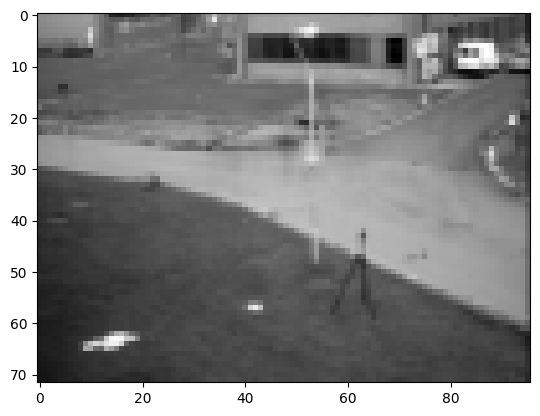

In [20]:
plt.imshow(np.reshape(low_rank[:,140], dims), cmap='gray');

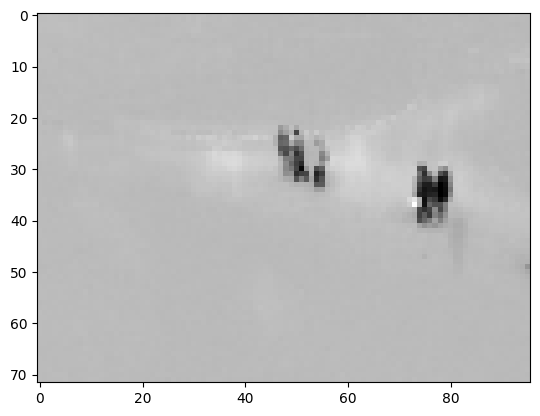

In [21]:
plt.imshow(np.reshape(M[:,550] - low_rank[:,550], dims), cmap='gray');

#### Rank 1 Approximation

In [15]:
u, s, v = decomposition.randomized_svd(M, 1)

In [16]:
u.shape, s.shape, v.shape

((6912, 1), (1,), (1, 11300))

In [17]:
low_rank = u @ np.diag(s) @ v

In [18]:
low_rank.shape

(6912, 11300)

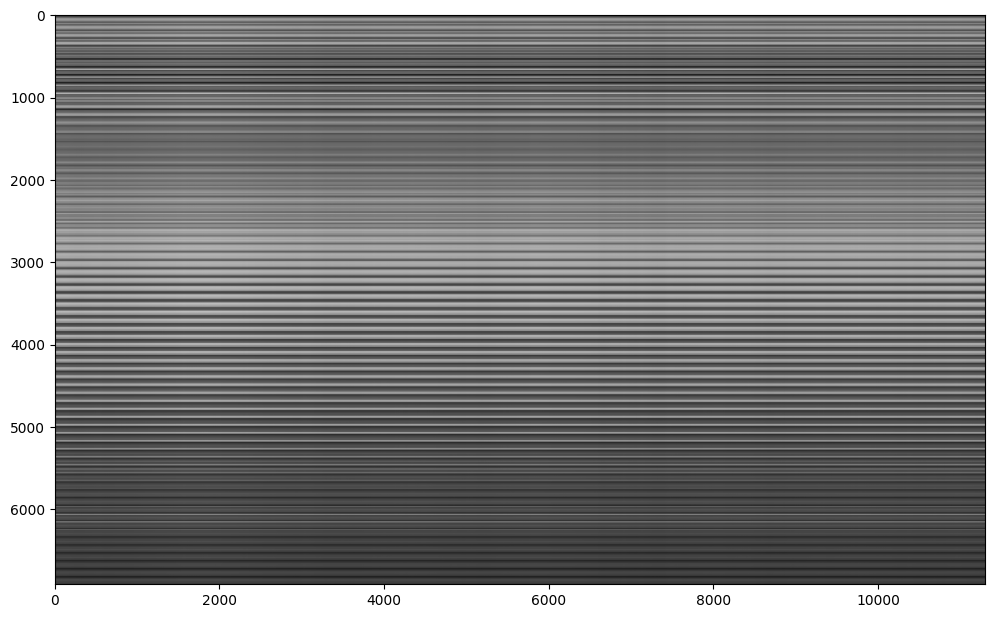

In [19]:
plt.figure(figsize=(12, 12))
plt.imshow(low_rank, cmap='gray')

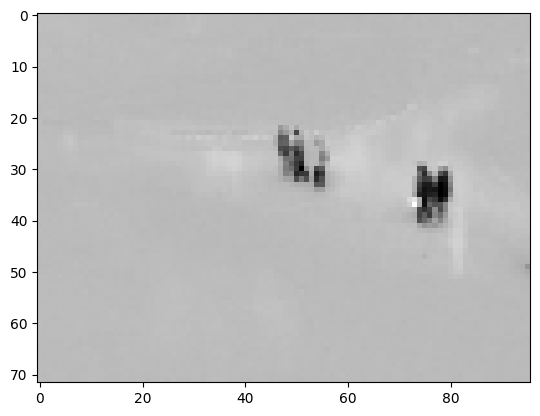

In [20]:
plt.imshow(np.reshape(M[:,550] - low_rank[:,550], dims), cmap='gray');

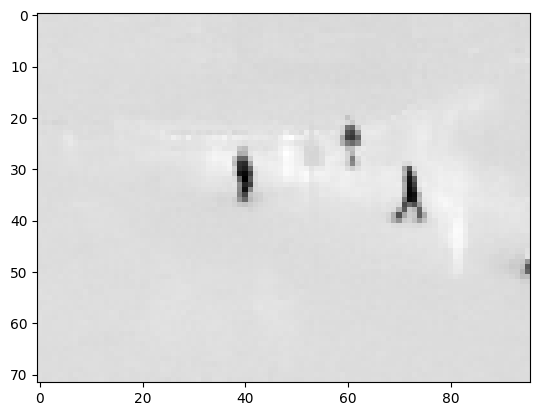

In [23]:
plt.imshow(np.reshape(M[:,140] - low_rank[:,140], dims), cmap='gray');

Let's zoom in on the people:

(72, 96)


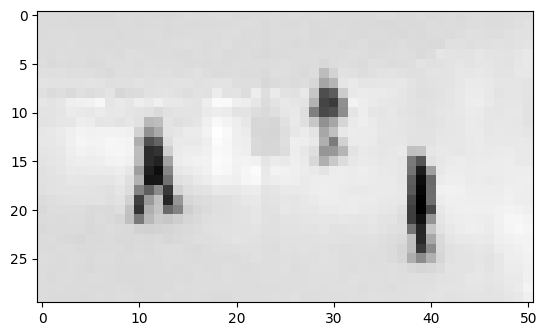

In [52]:
plt.imshow(np.reshape(M[:,169] - low_rank[:,169], dims)[15:45,30:81], cmap='gray');  # these indices we can find from above diagram
print(np.reshape(M[:,169]-low_rank[:,169],dims).shape)

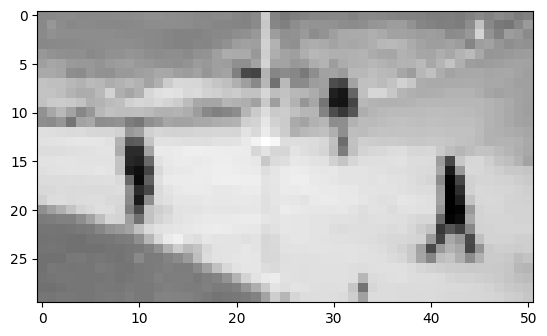

In [51]:
plt.imshow(np.reshape(M[:,140], dims)[15:45,30:81], cmap='gray') #foreground + background

In [31]:
#from moviepy.video.io.bindings import mplfig_to_npimage
from moviepy import VideoClip


def video_from_matrix(matrix,dims,fps=10, filename="out.mp4"):
    frames= matrix.shape[1]

    def make_vid(t):
        frame_idx= int(t*fps)
        if frame_idx >= frames:
            frame_idx = frames-1

        frame=matrix[:,frame_idx].reshape(dims)
        if frame.max() == frame.min():
            frame_normalized = np.zeros(dims)
        else:
            frame_normalized = (frame - frame.min()) / (frame.max() - frame.min()) * 255
        frame_uint8 = frame_normalized.astype(np.uint8)
        return np.stack([frame_uint8, frame_uint8, frame_uint8], axis=-1)

    dur=frames/fps
    clip=mpe.VideoClip(make_vid,duration=dur)

    clip.write_videofile(filename,fps=fps)

back=video_from_matrix(low_rank,dims,fps=100,filename="back.mp4")
front=video_from_matrix(M-low_rank,dims,fps=100,filename="front.mp4")

MoviePy - Building video back.mp4.
MoviePy - Writing video back.mp4



MoviePy - Done !
MoviePy - video ready back.mp4
MoviePy - Building video front.mp4.
MoviePy - Writing video front.mp4



MoviePy - Done !
MoviePy - video ready front.mp4


In [32]:
display(Video("data/video_003.mp4",width=300,embed=True))
display(Video("back.mp4", width=300, embed=True))
display(Video("front.mp4",width=300,embed=True))

This is amazing for such a simple approach! We can see the people clearly separated from the background.

### So Why Do We Need Robust PCA?

Both PCA and truncated SVD fundamentally solve the same problem: find the best rank-$k$ approximation of $M$. Under the hood, **PCA uses SVD**, they're mathematically equivalent.

The problem is what they **assume about our data**:

**Classical PCA/SVD assumes:**
- The low-rank structure is the "signal"
- Deviations are small, random noise: $M = L + \epsilon$ where $\epsilon \sim \mathcal{N}(0, \sigma^2)$
- You pre-specify the rank $k$

**But in background removal:**
- Deviations aren't small noise : they're **structured, large-magnitude events** (people walking)
- You don't know the rank beforehand
- A single large corruption (like a bright person on a dark background) can skew all singular values

**Example of failure:** If someone in a white shirt walks through a dark scene, their brightness dominates the singular values. The SVD "sees" them as part of the main pattern, not as a deviation.

### What Makes Robust PCA Different?

Robust PCA explicitly models **two types of structure**:

$$M = L + S$$

- $L$: Low-rank (background) : captures global, repetitive patterns
- $S$: Sparse (foreground) : captures localized, rare events

**Key insight:** Instead of treating foreground as "noise to ignore," RPCA treats it as "structured signal to extract." The optimization simultaneously finds:
1. The best low-rank matrix $L$ (background)
2. The sparsest matrix $S$ (foreground)

This dual objective is what makes it robust. Even if $S$ has large values, they're confined to a few entries, so they don't corrupt the low-rank structure of $L$.

### The Practical Difference

| Approach | How it works | Best for |
|----------|-------------|----------|
| **Truncated SVD/PCA** | Fix rank $k$, minimize $\|M - L\|$ | Small Gaussian noise, known dimensionality |
| **Robust PCA** | Optimize rank + sparsity jointly | Large structured corruptions, unknown rank |

For our surveillance video:
- **Naive SVD (rank-1):** Works decently, but requires manual rank tuning and struggles with bright foreground objects
- **Robust PCA:** Automatically balances background complexity with foreground sparsity ... no rank guessing needed

### The Robust PCA Solution

Robust PCA solves this by explicitly modeling two components:

$$\text{minimize} \quad \lVert L \rVert_* + \lambda\lVert S \rVert_1$$
$$\text{subject to} \quad L + S = M$$

Where:
- $\lVert L \rVert_*$ is the **nuclear norm** (sum of singular values). Minimizing this pushes $L$ toward low rank.
- $\lVert S \rVert_1$ is the **L1 norm** (sum of absolute values). Minimizing this pushes $S$ toward sparsity.
- $\lambda$ balances the two objectives (typically $\lambda = 1/\sqrt{m}$ where $m$ is the number of rows).



## Principal Component Analysis (PCA)

When dealing with high-dimensional data sets, we often leverage on the fact that the data has **low intrinsic dimensionality** in order to alleviate the curse of dimensionality and scale (perhaps it lies in a low-dimensional subspace or lies on a low-dimensional manifold). [Principal component analysis](http://setosa.io/ev/principal-component-analysis/) is handy for eliminating dimensions.  Classical PCA seeks the best rank-$k$ estimate $L$ of $M$ (minimizing $\| M - L \|$ where $L$ has rank-$k$).  Truncated SVD makes this calculation!

Traditional PCA can handle small noise, but is brittle with respect to grossly corrupted observations-- even one grossly corrupt observation can significantly mess up answer.

**Robust PCA** factors a matrix into the sum of two matrices, $M = L + S$, where $M$ is the original matrix, $L$ is **low-rank**, and $S$ is **sparse**.  This is what we'll be using for the background removal problem! **Low-rank** means that the matrix has a lot of redundant information-- in this case, it's the background, which is the same in every scene (talk about redundant info!).  **Sparse** means that the matrix has mostly zero entries-- in this case, see how the picture of the foreground (the people) is mostly empty.  (In the case of corrupted data, $S$ is capturing the corrupted entries).

### Applications of Robust PCA
- **Video Surveillance**

- **Face Recognition** photos from this excellent [tutorial](https://jeankossaifi.github.io/tensorly/rpca.html).  The dataset here consists of images of the faces of several people taken from the same angle but with different illumniations.

  <img src="images/faces_rpca.png" alt="Robust PCA" style="width: 80%"/>
  ([Source: Jean Kossaifi](https://jeankossaifi.github.io/tensorly/rpca.html))

  <img src="images/faces_rpca_gross.png" alt="Robust PCA" style="width: 80%"/>
  ([Source: Jean Kossaifi](https://jeankossaifi.github.io/tensorly/rpca.html))

- Latent Semantic Indexing: $L$ captures common words used in all documents while $S$ captures the few key words that best distinguish each document from others

- Ranking and Collaborative Filtering: a small portion of the available rankings could be noisy and even tampered with (see [Netflix RAD - Outlier Detection on Big Data](http://techblog.netflix.com/2015/02/rad-outlier-detection-on-big-data.html) on the official netflix blog)

### L1 norm induces sparsity

The unit ball $\lVert x \rVert_1 = 1$ is a diamond in the L1 norm.  It's extrema are the corners:

<img src="images/L1vsL2.jpg" alt="L1 norm" style="width: 60%"/>
([Source](https://www.quora.com/Why-is-L1-regularization-supposed-to-lead-to-sparsity-than-L2))
  
A similar perspective is to look at the *contours* of the loss function:
<img src="images/L1vsL2_2.png" alt="L2 norm" style="width: 60%"/>
([Source](https://www.quora.com/Why-is-L1-regularization-better-than-L2-regularization-provided-that-all-Norms-are-equivalent))

### Why These Norms Matter

**L1 norm creates sparsity.** Picture an optimization problem: you're trying to minimize some loss function while keeping $\lVert x \rVert_1 = 1$. In 2D, the L1 unit ball is a diamond. The optimal solution tends to hit the corners where most coordinates are zero. That's sparsity.

**Nuclear norm creates low rank.** The nuclear norm is just the L1 norm applied to singular values. Small singular values get driven to zero, leaving only a few large ones. Fewer singular values = lower rank.

### Optimization Problem

Robust PCA can be written:

$$ minimize\; \lVert L \rVert_* + \lambda\lVert S \rVert_1 \\ subject\;to\; L + S = M$$
 
where:

- $\lVert \cdot \rVert_1$ is the **L1 norm**.  Minimizing the [L1 norm](https://medium.com/@shiyan/l1-norm-regularization-and-sparsity-explained-for-dummies-5b0e4be3938a) results in sparse values.  For a matrix, the L1 norm is equal to the [maximum absolute column norm](https://math.stackexchange.com/questions/519279/why-is-the-matrix-norm-a-1-maximum-absolute-column-sum-of-the-matrix).

- $ \lVert \cdot \rVert_* $ is the **nuclear norm**, which is the L1 norm of the singular values.  Trying to minimize this results in sparse singular values --> low rank.


### Implementing an algorithm from a paper

We use the **Augmented Lagrange Multiplier (ALM)** method from [Lin, Chen, Ma 2010](https://arxiv.org/pdf/1009.5055.pdf). (n the specific form of **Matrix Completion via the Inexact ALM Method** found in [section 3.1 of this paper](https://arxiv.org/pdf/1009.5055.pdf) (Lin, Chen, Ma).) The core loop alternates between:

1. **Update S** (sparse component): Apply soft-thresholding (shrinkage operator)
2. **Update L** (low-rank component): Truncated SVD with singular value thresholding
3. **Update Y** (Lagrange multiplier): Gradient step on the constraint

Here's the intuition: we're trying to split $M$ into two parts. Each update refines one part while holding the other fixed, then we update our "error tracker" (the multiplier $Y$) to guide the next iteration.

### Detailed Algorithm Walkthrough

**Notation:**
- $M$ = original matrix (video)
- $L$ = low-rank matrix (background) — what we're solving for
- $S$ = sparse matrix (foreground) — what we're solving for
- $Y$ = Lagrange multiplier matrix — tracks constraint violations
- $\mu$ = penalty parameter — controls how strictly we enforce $L + S = M$
- $\lambda$ = sparsity weight — balances low-rank vs sparse objectives
- $\rho$ = step size for increasing $\mu$

#### The Good Parts

Section 1 of Candes, Li, Ma, Wright is nicely written, and section 5 Algorithms is our key interest.  **You don't need to know the math or understand the proofs to implement an algorithm from a paper.**  You will need to try different things and comb through resources for useful tidbits.  This field has more theoretical researchers and less pragmatic advice.  It took months to find what I needed and get this working.

The algorithm shows up on page 29:

 <img src="images/pcp_algorithm.png" alt="PCP algorithm" style="width: 100%"/>

needed definitions of $\mathcal{S}$, the Shrinkage operator, and $\mathcal{D}$, the singular value thresholding operator:

 <img src="images/candes.png" alt="PCP algorithm" style="width: 100%"/>

Section 3.1 of [Chen, Lin, Ma]() contains a faster vartiation of this:

 <img src="images/rpca_inexact.png" alt="Inexact RPCA" style="width: 80%"/>

And Section 4 has some very helpful implementation details on how many singular values to calculate (as well as how to choose the parameter values):

 <img src="images/svp_value.png" alt="SVP values" style="width:70%"/> 

## Robust PCA (via Primary Component Pursuit)

### Methods

We will use [Facebook's Fast Randomized PCA](https://github.com/facebook/fbpca) library.

In [12]:
from scipy import sparse
from sklearn.utils.extmath import randomized_svd
import fbpca

In [13]:
TOL=1e-9
MAX_ITERS=3

In [14]:
def converged(Z, d_norm):
    err = np.linalg.norm(Z, 'fro') / d_norm
    print('error: ', err)
    return err < TOL

In [15]:
def shrink(M, tau):
    S = np.abs(M) - tau
    return np.sign(M) * np.where(S>0, S, 0)

In [16]:
def _svd(M, rank): return fbpca.pca(M, k=min(rank, np.min(M.shape)), raw=True)

In [17]:
def norm_op(M): return _svd(M, 1)[1][0]

In [18]:
def svd_reconstruct(M, rank, min_sv):
    u, s, v = _svd(M, rank)
    s -= min_sv
    nnz = (s > 0).sum()
    return u[:,:nnz] @ np.diag(s[:nnz]) @ v[:nnz], nnz

In [19]:
def pcp(X, maxiter=10, k=10): # refactored
    m, n = X.shape
    trans = m<n
    if trans: X = X.T; m, n = X.shape
        
    lamda = 1/np.sqrt(m)
    op_norm = norm_op(X)
    Y = np.copy(X) / max(op_norm, np.linalg.norm( X, np.inf) / lamda)
    mu = k*1.25/op_norm; mu_bar = mu * 1e7; rho = k * 1.5
    
    d_norm = np.linalg.norm(X, 'fro')
    L = np.zeros_like(X); sv = 1
    
    examples = []
    
    for i in range(maxiter):
        print("rank sv:", sv)
        X2 = X + Y/mu
        
        # update estimate of Sparse Matrix by "shrinking/truncating": original - low-rank
        S = shrink(X2 - L, lamda/mu)
        
        # update estimate of Low-rank Matrix by doing truncated SVD of rank sv & reconstructing.
        # count of singular values > 1/mu is returned as svp
        L, svp = svd_reconstruct(X2 - S, sv, 1/mu)
        
        # If svp < sv, we are already calculating enough singular values.
        # If not, add 20% (in this case 240) to sv
        sv = svp + (1 if svp < sv else round(0.05*n))
        
        # residual
        Z = X - L - S
        Y += mu*Z; mu *= rho
        
        examples.extend([S[140,:], L[140,:]])
        
        if m > mu_bar: m = mu_bar
        if converged(Z, d_norm): break
    
    if trans: L=L.T; S=S.T
    return L, S, examples

the algorithm again (page 29 of [Candes, Li, Ma, and Wright](https://arxiv.org/pdf/0912.3599.pdf))

 <img src="images/pcp_algorithm.png" alt="PCP algorithm" style="width: 100%"/>

**What Each Step Does:**

**Step 1 - Form Augmented Matrix:** 
$X_2 = M + Y/\mu$ incorporates both the original data and our current estimate of constraint violations.

**Step 2 - Update S (Shrinkage):**
The shrinkage operator $\mathcal{S}_\tau$ solves:
$$\mathcal{S}_\tau(x) = \text{sign}(x) \cdot \max(|x| - \tau, 0)$$

This is the solution to: $\min_s \tau|s| + \frac{1}{2}(x - s)^2$

Applied element-wise, it pushes small values to zero (creating sparsity) while preserving large values (the foreground).

**Step 3 - Update L (SVD Thresholding):**
The singular value thresholding operator $\mathcal{D}_\tau$ computes:
1. $X_2 - S = U\Sigma V^T$ (truncated SVD)
2. $\tilde{\Sigma} = \max(\Sigma - \tau I, 0)$ (shrink singular values)
3. $L = U\tilde{\Sigma}V^T$ (reconstruct with thresholded values)

This solves: $\min_L \tau\|L\|_* + \frac{1}{2}\|X_2 - S - L\|^2_F$

Thresholding singular values pushes small ones to zero, reducing the rank of $L$.

**Step 4 - Adaptive Rank Selection:**
- If $\text{svp} < \text{sv}$: We had enough singular values, just increment by 1
- If $\text{svp} = \text{sv}$: We used all of them, might need more, add 5% of matrix width (~565 for our video)

This prevents getting stuck with too few singular values.

**Step 5 - Multiplier Update:**
$Y_{k+1} = Y_k + \mu(M - L - S)$ is gradient ascent on the Lagrangian. $Y$ accumulates violations of the constraint $L + S = M$.

**Step 6 - Penalty Increase:**
$\mu_{k+1} = \rho \cdot \mu_k$ makes the algorithm progressively enforce the constraint more strictly.

### Why This Works: The Lagrangian View

We're solving the constrained problem:
$$\min_{L,S} \|L\|_* + \lambda\|S\|_1 \quad \text{s.t.} \quad L + S = M$$

The **augmented Lagrangian** is:
$$\mathcal{L}(L, S, Y, \mu) = \|L\|_* + \lambda\|S\|_1 + \langle Y, M - L - S \rangle + \frac{\mu}{2}\|M - L - S\|^2_F$$

Where:
- $\langle Y, M - L - S \rangle$ = penalty for violating constraint (linear term)
- $\frac{\mu}{2}\|M - L - S\|^2_F$ = quadratic penalty for violating constraint

The ALM method alternates between:
- Minimizing over $L$ (holding $S, Y$ fixed)
- Minimizing over $S$ (holding $L, Y$ fixed)  
- Gradient ascent on $Y$ (dual variable)
- Increasing $\mu$ (tightening enforcement)

This converges to the solution of the original constrained problem.

### Results

In [20]:
m, n = M.shape
round(m * .05)

346

In [21]:
L, S, examples =  pcp(M, maxiter=3, k=10)

rank sv: 1
error:  0.13547329521946802
rank sv: 347
error:  0.04993039825651362
rank sv: 56
error:  0.006479660049227062


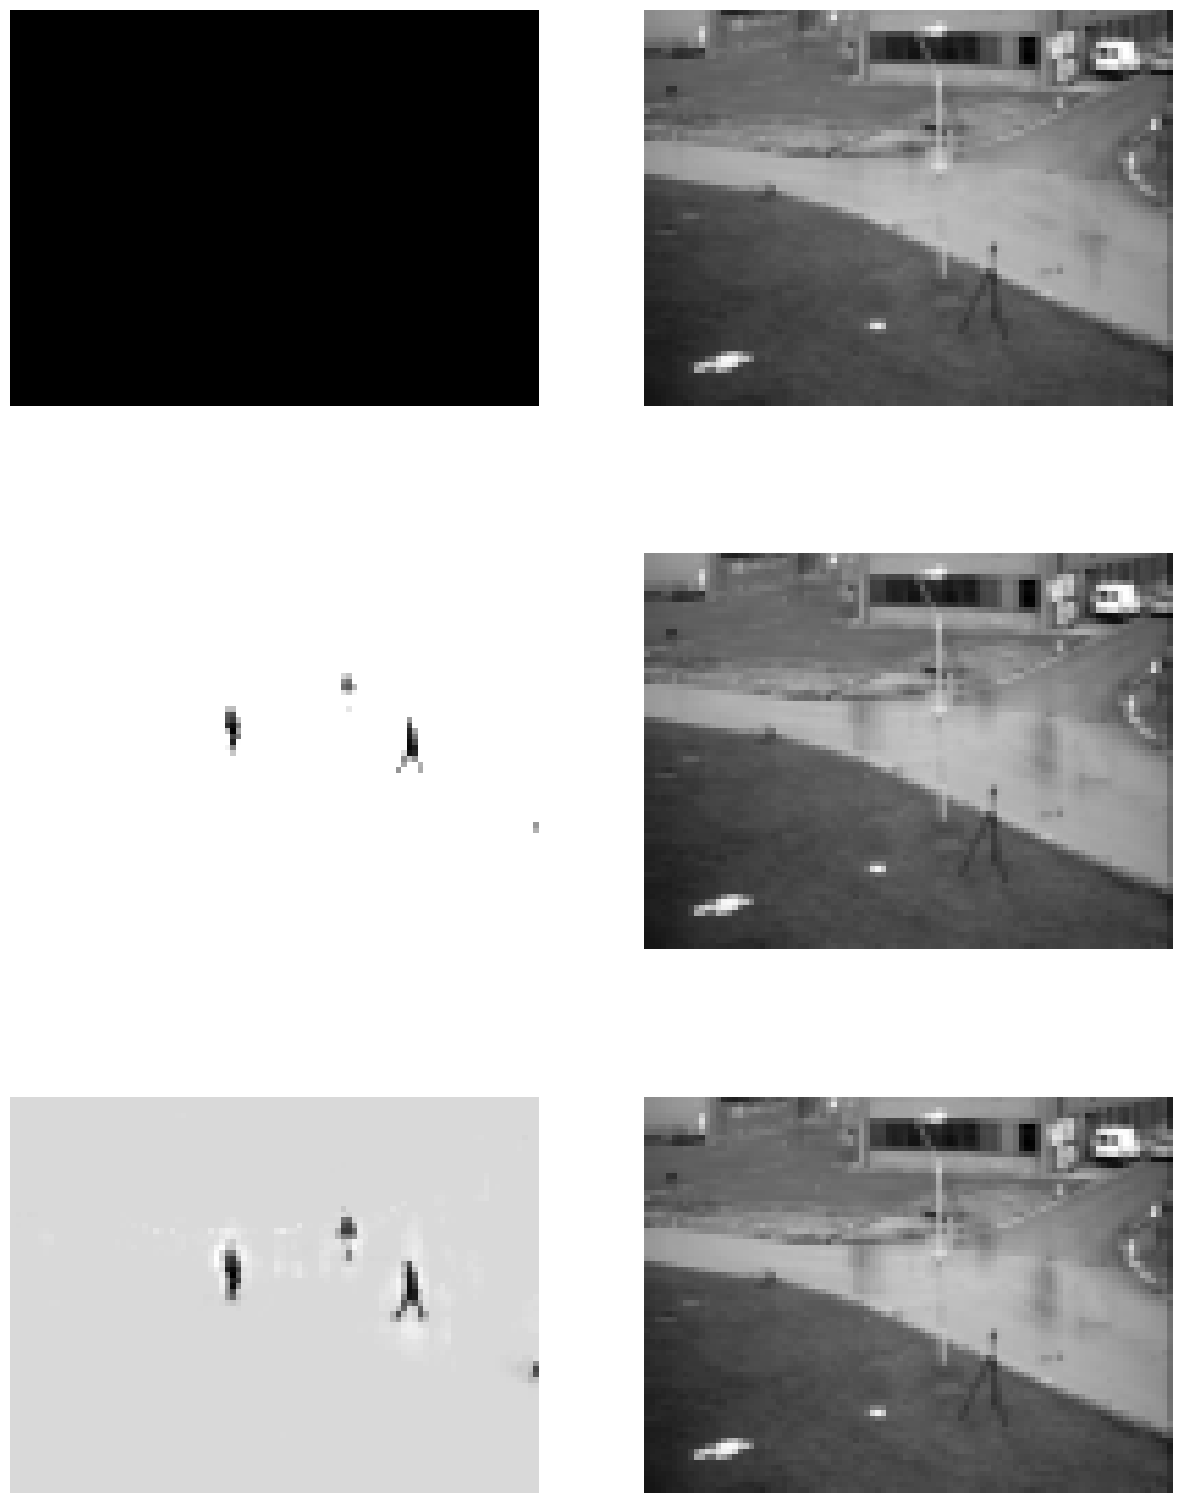

In [23]:
plots(examples, dims, rows=3)

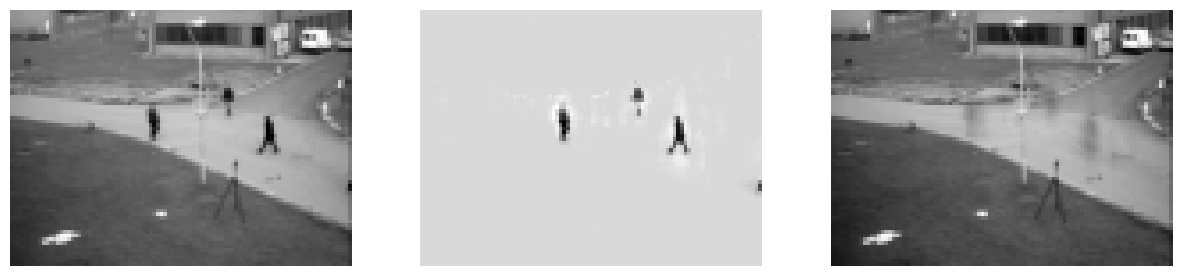

In [24]:
f = plt_images(M, S, L, [140], dims)

In [37]:
np.save("high_res_L.npy", L)
np.save("high_res_S.npy", S)

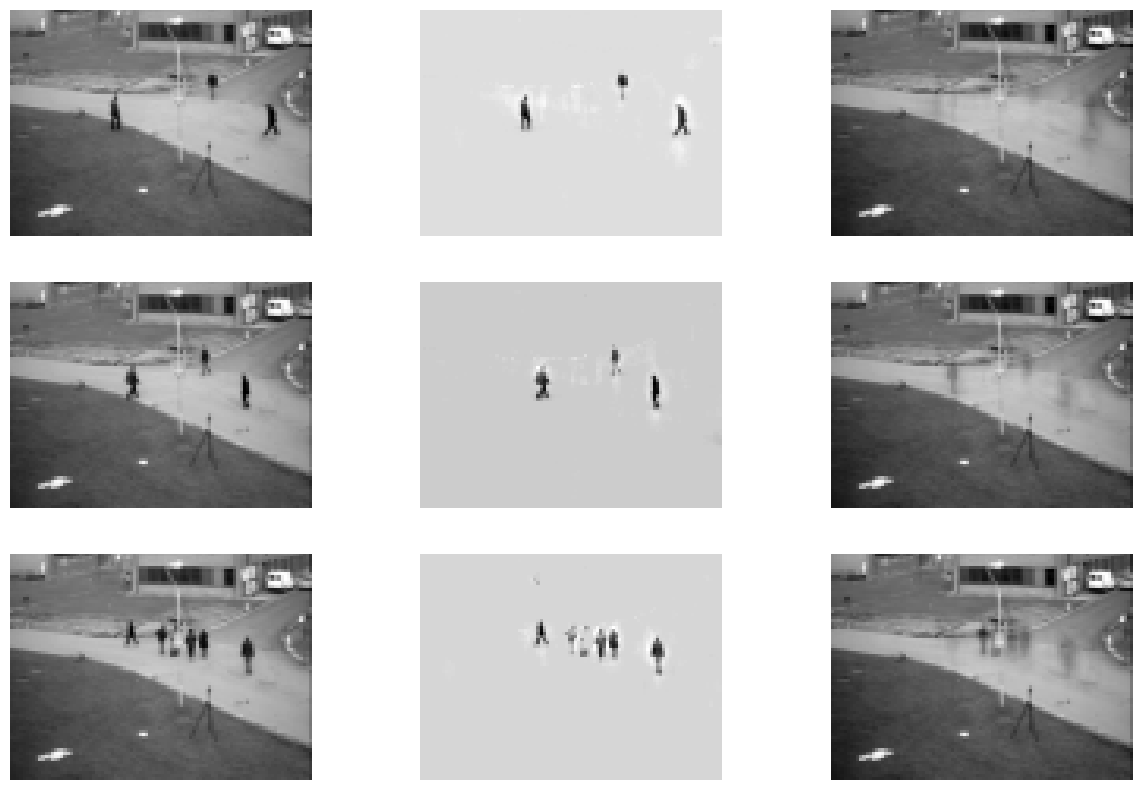

In [25]:
f = plt_images(M, S, L, [0, 100, 1000], dims)

Extracting a bit of the foreground is easier than identifying the background.  To accurately get the background, you need to remove all the foreground, not just parts of it

# End